# CATBoost

In [ ]:
import pandas as pd 
df = pd.read_csv("./data/ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])

import numpy as np
import matplotlib.pyplot as plt
import warnings
import platform
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,roc_auc_score, precision_recall_curve, average_precision_score)
from catboost import CatBoostClassifier
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("=" * 60)
print("로드 완료")
print("=" * 60)

C:\Users\didwn\AppData\Local\Temp\ipykernel_7308\547299509.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("./data/ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])


로드 완료


## 변수 선택

In [2]:
# 모델을 위해 최적화된 변수 선택 
use_col = [
    # ── 타겟 ──
    "target",                        # 부도 여부 (0/1)
    # ── 대출 기본 정보 ──
    "loan_amnt",                     # 대출 금액
    "term",                          # 기간 (36/60개월)
    "int_rate",                      # 이자율
    "sub_grade",                     # 등급 세분류 (A1~G5)
    "installment",                   # 월 상환액 ($)
    "purpose",                       # 대출 목적
    "issue_year",                    # 대출 실행 연도
    # ── 차입자 정보 ──
    "emp_length",                    # 근속 연수
    "home_ownership",                # 주거 형태
    "annual_inc",                    # 자기보고 연소득 ($)
    # ── 부채 관련 지표 ──
    "dti",                           # 부채 대비 소득 비율
    "fico_mid",                      # FICO 점수 평균
    "pub_rec",                       # 공공 부정 기록 건수
    # ── 계좌 잔액 / 한도 ──
    "avg_cur_bal",                   # 전체 계좌 평균 잔액 ($)
    "revol_bal",                     # 리볼빙 총 잔액 ($)
    "revol_util",                    # 리볼빙 이용률 (%)
    "total_rev_hi_lim",              # 전체 리볼빙 신용 한도 ($)
    "bc_open_to_buy",                # 뱅크카드 잔여 한도 ($)
    "total_bc_limit",                # 뱅크카드 총 한도 ($)
    "tot_hi_cred_lim",               # 전체 계좌 신용한도 합계 ($)
    # ── 계좌 수량 ──
    "num_actv_bc_tl",                # 활성 뱅크카드 수
    "num_actv_rev_tl",               # 활성 리볼빙 계좌 수
    "num_rev_tl_bal_gt_0",           # 잔액 > 0인 리볼빙 계좌 수
    "num_il_tl",                     # 할부 계좌 수
    "total_acc",                     # 전체 신용 계좌 수
    "acc_open_past_24mths",          # 최근 24개월 신규 계좌 수
    # ── 계좌 경과 기간 ──
    "mo_sin_old_rev_tl_op",          # 가장 오래된 리볼빙 계좌 경과 월수
    "mo_sin_rcnt_rev_tl_op",         # 가장 최근 리볼빙 계좌 경과 월수
    "mo_sin_old_il_acct",            # 가장 오래된 할부 계좌 경과 월수
    "mths_since_recent_bc",          # 최근 뱅크카드 개설 경과 월수
    "mths_since_recent_inq",         # 최근 신용 조회 경과 월수
    "mths_since_rcnt_il",            # 최근 할부 계좌 경과 월수 
    # ── 연체 경과 (mths_since 계열) ──
    "mths_since_last_delinq",        # 마지막 연체 경과 월수 
    "mths_since_last_major_derog",   # 마지막 주요 부정 기록 경과 월수 
    "mths_since_recent_revol_delinq",# 최근 리볼빙 연체 경과 월수
    "mths_since_recent_bc_dlq",      # 최근 뱅크카드 연체 경과 월수 
    # ── 연체 이력 지표 ──
    "pct_tl_nvr_dlq",                # 연체 없는 계좌 비율 (%)
    # ── 파생 플래그 ──
    "mths_since_last_major_derog_flag", #  마지막 주요 부정 기록 경과 (Y/N)1 
    "mths_since_recent_inq_flag" ,  # 가장 최근 신용 조회 이후 경과 월수 (Y/N)1
    "issue_d", "earliest_cr_line"
]

df = df[use_col]


In [ ]:
# 파생컬럼 
# 날짜형 변수 년, 월 단위 변수(issue_year, issue_month) 생성 
df['issue_year'] = df['issue_d'].dt.year.astype(str)
df['issue_month'] = df['issue_d'].dt.month.astype(str) 

# 신용계좌 개설일 날짜형 변수 년 단위 변수 생성
df["earliest_cr_line_year"]= pd.to_datetime(df["earliest_cr_line"]).dt.year.astype(str)

# 월 상환 부담율(installment_to_income) 생성
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12) 

# 대출규모 대비 소득(loan_to_income) 생성
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'] 

# 회전부채 대비 소득(revol_bal_to_income) 생성
df['revol_bal_to_income'] = df['revol_bal'] / df['annual_inc'] #  revol_bal_to_income (회전부채 대비 소득)

#숫자 잘못 처리 되었을 때 NaN 처리
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income']
for col in new_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# 생성후 Drop / "annual_inc", "revol_bal","installment" 은 개인 판단으로 고고 저는 뺄예정 
df = df.drop(columns=["issue_d", "earliest_cr_line", "annual_inc", "revol_bal","installment"])


print(f"전체: {len(df.columns)}")
print(f"고유: {len(set(df.columns))}")

전체: 42
고유: 42


In [4]:
# 전체 컬럼의 null 여부 
null_info = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측률': df.isnull().mean().apply(lambda x: f"{x:.2%}")
})
print(null_info[null_info['결측수'] > 0])

                                   결측수     결측률
dti                                414   0.03%
mo_sin_old_il_acct               38045   2.98%
mths_since_recent_bc             12685   0.99%
mths_since_recent_inq           124121   9.71%
mths_since_rcnt_il              754388  59.04%
mths_since_last_delinq          634712  49.67%
mths_since_last_major_derog     924045  72.32%
mths_since_recent_revol_delinq  832930  65.18%
mths_since_recent_bc_dlq        958775  75.03%
pct_tl_nvr_dlq                     154   0.01%
installment_to_income              361   0.03%
loan_to_income                     361   0.03%
revol_bal_to_income                361   0.03%


## Train/Test 분리

In [6]:
#  분리
y = df["target"] # target
X = df.drop(columns=["target"]) # 설명 변수 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 컬럼 구분 

num_cols  = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"수치형: {len(num_cols)}개\n{num_cols}\n")
print(f"범주형: {len(cat_cols)}개\n{cat_cols}")

수치형: 31개
['loan_amnt', 'int_rate', 'dti', 'fico_mid', 'pub_rec', 'avg_cur_bal', 'revol_util', 'total_rev_hi_lim', 'bc_open_to_buy', 'total_bc_limit', 'tot_hi_cred_lim', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_rev_tl_bal_gt_0', 'num_il_tl', 'total_acc', 'acc_open_past_24mths', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_old_il_acct', 'mths_since_recent_bc', 'mths_since_recent_inq', 'mths_since_rcnt_il', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_recent_revol_delinq', 'mths_since_recent_bc_dlq', 'pct_tl_nvr_dlq', 'installment_to_income', 'loan_to_income', 'revol_bal_to_income']

범주형: 10개
['term', 'sub_grade', 'purpose', 'issue_year', 'emp_length', 'home_ownership', 'mths_since_last_major_derog_flag', 'mths_since_recent_inq_flag', 'issue_month', 'earliest_cr_line_year']


## 결측치 

In [7]:
# 전체 컬럼의 null 여부 
null_info = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측률': df.isnull().mean().apply(lambda x: f"{x:.2%}")
})
print(null_info[null_info['결측수'] > 0])

                                   결측수     결측률
dti                                414   0.03%
mo_sin_old_il_acct               38045   2.98%
mths_since_recent_bc             12685   0.99%
mths_since_recent_inq           124121   9.71%
mths_since_rcnt_il              754388  59.04%
mths_since_last_delinq          634712  49.67%
mths_since_last_major_derog     924045  72.32%
mths_since_recent_revol_delinq  832930  65.18%
mths_since_recent_bc_dlq        958775  75.03%
pct_tl_nvr_dlq                     154   0.01%
installment_to_income              361   0.03%
loan_to_income                     361   0.03%
revol_bal_to_income                361   0.03%


In [8]:
# 결측 처리 
# test data로 결측 처리 
# dti sub_grade 별 중앙값으로 채우기 
X_train["dti"] = X_train.groupby("sub_grade")["dti"].transform(
    lambda x: x.fillna(x.median())
)

train_dit_medi = X_train.groupby("sub_grade")["dti"].median()

X_test["dti"] = X_test["dti"].fillna(X_test["sub_grade"].map(train_dit_medi))


## mo_sin_old_il_acct  가장 오래된 할부 계좌 이후 경과 월수
## 0 으로 
X_train["mo_sin_old_il_acct"] = X_train["mo_sin_old_il_acct"].fillna(0) 
X_test["mo_sin_old_il_acct"] =  X_test["mo_sin_old_il_acct"].fillna(0) 


# mths_since_rcnt_il 가장 최근 할부 계좌(Installment Loan) 개설 이후 경과 월수
## 중앙값으로 채우기 
medi_rcnt_il = X_train["mths_since_rcnt_il"].median()
X_train["mths_since_rcnt_il"] = X_train["mths_since_rcnt_il"].fillna(medi_rcnt_il)
X_test["mths_since_rcnt_il"] = X_test["mths_since_rcnt_il"].fillna(medi_rcnt_il)



# 파생변수 결측값 채우기(★train/test 이후 결측값 채우기)
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income',]
for col in new_cols:
    train_median = X_train[col].median()                   
    X_train[col] = X_train[col].fillna(train_median)      
    X_test[col] = X_test[col].fillna(train_median)       


    # 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_recent_inq',
'mths_since_recent_bc'
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1)
    X_test[col] = X_test[col].fillna(max_val + 1)


# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = X_train["pct_tl_nvr_dlq"].median()
X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

In [9]:
# 확인
null_train = X_train.isnull().sum()
print(null_train[null_train>0])

null_test = X_test.isnull().sum()
print(null_test[null_test>0])

Series([], dtype: int64)
Series([], dtype: int64)


## 불균형 데이터 극복 SMOTE + NC
- (Synthetic Minority Over-sampling Technique)

In [ ]:
from imblearn.over_sampling import SMOTENC
import joblib
# 1. 범주형 컬럼 인덱스 (X_train 기준)
cat_idx = [X_train.columns.get_loc(col) for col in cat_cols]

# 2. SMOTENC 적용
smotenc = SMOTENC(
    categorical_features=cat_idx,
    sampling_strategy=1.0,  # 50:50
    random_state=42,
    k_neighbors=5
)

# X,Y 분리된 채사용. fit_resample
X_smote, y_smote = smotenc.fit_resample(X_train, y_train)

# 3. 확인
print(pd.Series(y_smote).value_counts(normalize=True))
print(f"증강 전: {X_train.shape} → 증강 후: {X_smote.shape}")


target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64
증강 전: (1022239, 41) → 증강 후: (1631242, 41)


FileNotFoundError: [Errno 2] No such file or directory: './models/smote_sam_data.pkl'

In [14]:

# 저장 !!!
joblib.dump((X_smote, y_smote), "./model/smote_sam_data.pkl")

['./model/smote_sam_data.pkl']

In [11]:
# 샘플 데이터 블러오기 
import joblib
X_smote, y_smote = joblib.load("./model/smote_sam_data.pkl")
print(X_smote.shape)
print(pd.Series(y_smote).value_counts(normalize=True))

(1631242, 41)
target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


## 모델 제작  

- Cat_boost 학습
- 1단계: learning_rate 고정 (0.1) + n_estimators를 early stopping으로 결정
- 2단계: max_depth, min_child_weight 튜닝 (트리 복잡도)
- 3단계: subsample, colsample_bytree 튜닝 (샘플링)
- 4단계: reg_alpha, reg_lambda 튜닝 (규제)
- 5단계: learning_rate 줄이고 n_estimators 늘리기 (정밀화)

###  1단계: learning_rate 고정 (0.1), n_estimators를 early stopping으로 결정

- f1 사용 
- bestTest = 0.8643603986
- bestIteration = 497

In [ ]:

# - 1단계: learning_rate 고정 (0.1) + n_estimators를 early stopping으로 결정
## 평가 지표 f1으로 

# validation 분리
X_tr, X_val, y_tr, y_val = train_test_split(
    X_smote, y_smote, test_size=0.1, random_state=42
)

# 1단계 모델 (learning_rate 0.1 고정)
cat_model_1 = CatBoostClassifier(
    learning_rate=0.1,
    depth=6,           # 임시 고정
    l2_leaf_reg=5,     # 임시 고정
    iterations=2000,   # 넉넉하게 # 1단계 
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=100,
    cat_features=cat_cols
)

cat_model_1.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

# 최적 iterations 확인
best_iterations = cat_model_1.best_iteration_
print(f"Best iterations: {best_iterations}")


# bestTest = 0.8643603986
# bestIteration = 497

# Shrink model to first 498 iterations.
# Best iterations: 497 고정 

0:	learn: 0.7313313	test: 0.7306806	best: 0.7306806 (0)	total: 489ms	remaining: 16m 17s
100:	learn: 0.8603282	test: 0.8614246	best: 0.8614246 (100)	total: 29s	remaining: 9m 5s
200:	learn: 0.8623494	test: 0.8629116	best: 0.8629624 (193)	total: 58.5s	remaining: 8m 43s
300:	learn: 0.8633816	test: 0.8636983	best: 0.8637017 (298)	total: 1m 28s	remaining: 8m 19s
400:	learn: 0.8640874	test: 0.8641215	best: 0.8641215 (400)	total: 1m 59s	remaining: 7m 55s
500:	learn: 0.8645917	test: 0.8643291	best: 0.8643604 (497)	total: 2m 29s	remaining: 7m 28s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8643603986
bestIteration = 497

Shrink model to first 498 iterations.
Best iterations: 497


In [ ]:
# --- 평가 ---


proba = cat_model_1.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC :", roc_auc_score(y_test, proba))

Accuracy: 0.8039090624510878
ROC-AUC : 0.735717352835533


In [ ]:

y_pred = cat_model_1.predict(X_test)
proba  = cat_model_1.predict_proba(X_test)[:, 1]  # 양성(1) 확률만 담기 
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# f1 0.2 

Test Accuracy: 0.8039090624510878
              precision    recall  f1-score   support

         0.0       0.81      0.98      0.89    203905
         1.0       0.57      0.12      0.20     51655

    accuracy                           0.80    255560
   macro avg       0.69      0.55      0.54    255560
weighted avg       0.77      0.80      0.75    255560



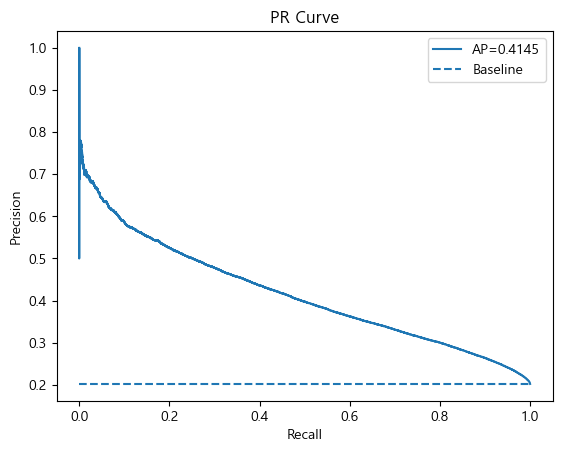

In [ ]:
# PR Curve
ap = average_precision_score(y_test, proba)
prec, rec, thresholds = precision_recall_curve(y_test, proba)

plt.plot(rec, prec, label=f"AP={ap:.4f}")
plt.hlines(y_test.mean(), 0, 1, linestyles="--", label="Baseline")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("PR Curve"); plt.legend(); plt.show()

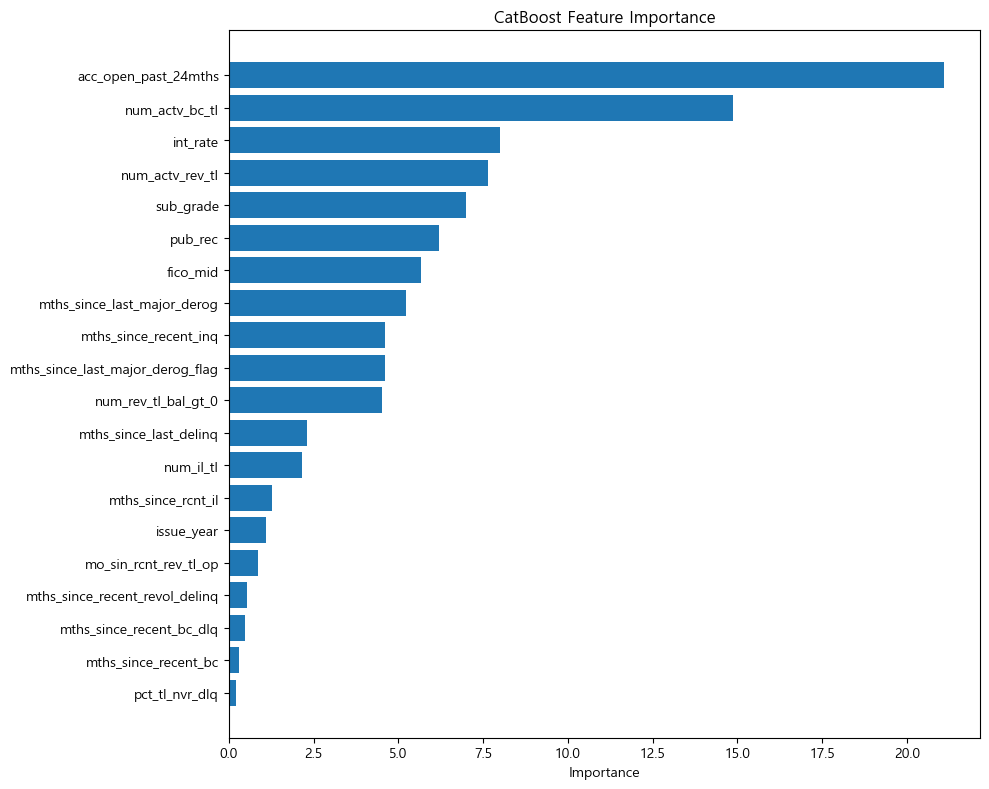

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 피처 중요도 추출
feature_importance = pd.DataFrame({
    "feature": X_tr.columns,
    "importance": cat_model_1.get_feature_importance()
}).sort_values("importance", ascending=False)

# 2. 상위 20개 시각화
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance["feature"][:20][::-1],
    feature_importance["importance"][:20][::-1]
)
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 2 단계  depth, min_data_in_leaf 튜닝 (트리 복잡도)

- f1 사용
- best depth: 6
- Best F1: 0.8628

In [ ]:
from sklearn.model_selection import GridSearchCV

# 샘플링 (2M행 → 20%만)
X_sample = X_smote.sample(frac=0.2, random_state=42)
y_sample = y_smote[X_sample.index]

# 2단계: depth 탐색
param_grid_2 = {
    "depth": [4, 6, 8, 10, 12]
}

gs_2 = GridSearchCV(
    CatBoostClassifier(
        iterations=497,        # 1단계에서 고정
        learning_rate=0.1,     # 고정
        l2_leaf_reg=5,         
        loss_function="Logloss",
        eval_metric="F1",
        random_seed=42,
        verbose=0
    ),
    param_grid=param_grid_2,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gs_2.fit(X_sample, y_sample, cat_features=cat_cols)

best_depth = gs_2.best_params_["depth"]
print(f"Best depth: {best_depth}")
print(f"Best F1: {gs_2.best_score_:.4f}")

# best depth: 6
# Best F1: 0.8628



Best depth: 6
Best F1: 0.8628


### 3단계: GridSearch(subsample, rsm)

- f1 사용 
- Best subsample: 1.0
- Best rsm: 1.0 
- >> 1, 1 샘플링 없이 전체 데이터 사용이 최적, 데이터가 크니까 필요 없었던 부분 
- Best F1: 0.8629

In [ ]:
param_grid_3 = {
    "subsample": [0.6, 0.8, 1.0],
    "rsm": [0.6, 0.8, 1.0]        # CatBoost의 colsample 대응
}

gs_3 = GridSearchCV(
    CatBoostClassifier(
        iterations=497,        # 1단계 고정
        learning_rate=0.1,     # 1단계 고정
        depth=6,               # 2단계 고정
        l2_leaf_reg=5,         # 1단계 고정
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0
    ),
    param_grid=param_grid_3,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gs_3.fit(X_sample, y_sample, cat_features=cat_cols)

best_subsample = gs_3.best_params_["subsample"]
best_rsm = gs_3.best_params_["rsm"]
print(f"Best subsample: {best_subsample}")
print(f"Best rsm: {best_rsm}")
print(f"Best F1: {gs_3.best_score_:.4f}")

# Best subsample: 1.0
# Best rsm: 1.0 
# >> 1, 1 샘플링 없이 전체 데이터 사용이 최적, 데이터가 크니까 필요 없었던 부분 
# Best F1: 0.8629

Best subsample: 1.0
Best rsm: 1.0
Best F1: 0.8629


### 4단계: l2_leaf_reg,  튜닝 (규제) 
- "min_data_in_leaf"도 같이 탐색
- 샘플링 30%로 올리기 
- 그리드 서치 판단 기준을 scoring="roc_auc", 로 변경 FN에 가중을 좀더주고 싶음 "전체 임계값 범위에서 최적화된 모델"
- f1기준으로 그리드 서치 해보니 큰 성능항샹이 없었음  

In [ ]:
# 4단계: 
from catboost import CatBoostClassifier

X_sample = X_smote.sample(frac=0.3, random_state=42)
y_sample = y_smote[X_sample.index]

param_grid_4 = {
    "l2_leaf_reg": [1, 3, 5, 7, 10, 15, 20, 30],
    "min_data_in_leaf": [1, 5, 10, 20, 50]
}

gs_4 = GridSearchCV(
    CatBoostClassifier(
        iterations=497,
        learning_rate=0.1,
        depth=6,
        subsample=1.0,         # 3단계 고정
        rsm=1.0,               # 3단계 고정
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0
    ),
    param_grid=param_grid_4,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gs_4.fit(X_sample, y_sample, cat_features=cat_cols)


# 4단계 결과 출력
best_l2 = gs_4.best_params_["l2_leaf_reg"]
best_min_leaf = gs_4.best_params_["min_data_in_leaf"]  # 추가
print(f"Best l2_leaf_reg: {best_l2}")
print(f"Best min_data_in_leaf: {best_min_leaf}")        # 추가
print(f"Best AUC: {gs_4.best_score_:.4f}")

# Best l2_leaf_reg: 1 데이터가 충분해서 규제 불필요
# Best min_data_in_leaf: 1 세밀한 분기 허용
# Best AUC: 0.9316
# SMOTENC로 2M행 충분히 확보 → 모델이 과적합 없이 세밀하게 학습 가능 → 규제 필요 없음

Best l2_leaf_reg: 1
Best min_data_in_leaf: 1
Best AUC: 0.9316


### - 5단계: learning_rate 줄이고 n_estimators 늘리기 (정밀화)

- 확정된 파라미터
1. iterations = 497
2. learning_rate = 0.1   # 5단계에서 낮춤
3. depth = 6
4. subsample = 1.0
5. rsm = 1.0
7. l2_leaf_reg = 1
8. min_data_in_leaf = 1

- eval_metric="AUC" 로 


In [ ]:
# 5단계: learning_rate 낮추고 iterations 늘려서 정밀화
cat_final = CatBoostClassifier(
    iterations=5000,           # 모델 트리를 몇개 만들 것이냐 
    learning_rate=0.01,        # 0.1 → 0.01로 낮추기 학습률 10배 감소, 수럼속도 10배 느려짐 iterations 도 10배 증가 
    depth=6,
    subsample=1.0,
    rsm=1.0,
    l2_leaf_reg=1,
    min_data_in_leaf=1,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=10,
    cat_features=cat_cols
)

# Early Stopping으로 최적 iterations 자동 결정
X_tr, X_val, y_tr, y_val = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42
)

cat_final.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100  
)

# bestTest = 0.9328663155
# bestIteration = 4999

# Best iteration: 4999


0:	test: 0.8166617	best: 0.8166617 (0)	total: 289ms	remaining: 24m 5s
10:	test: 0.8287800	best: 0.8290026 (8)	total: 2.48s	remaining: 18m 46s
20:	test: 0.8507444	best: 0.8507444 (20)	total: 5.15s	remaining: 20m 21s
30:	test: 0.8700471	best: 0.8706353 (29)	total: 7.7s	remaining: 20m 35s
40:	test: 0.8856348	best: 0.8856348 (40)	total: 10.5s	remaining: 21m 8s
50:	test: 0.8933631	best: 0.8933631 (50)	total: 13.2s	remaining: 21m 21s
60:	test: 0.8987804	best: 0.8987804 (60)	total: 16.1s	remaining: 21m 41s
70:	test: 0.9043203	best: 0.9043203 (70)	total: 18.8s	remaining: 21m 47s
80:	test: 0.9085560	best: 0.9085560 (80)	total: 21.8s	remaining: 22m 1s
90:	test: 0.9113327	best: 0.9113327 (90)	total: 24.4s	remaining: 21m 57s
100:	test: 0.9145789	best: 0.9145789 (100)	total: 27.1s	remaining: 21m 56s
110:	test: 0.9163998	best: 0.9163998 (110)	total: 29.9s	remaining: 21m 56s
120:	test: 0.9178657	best: 0.9178657 (120)	total: 32.6s	remaining: 21m 54s
130:	test: 0.9194374	best: 0.9194374 (130)	total: 35

NameError: name 'roc_auc_score' is not defined

In [ ]:

print(f"Best iteration: {cat_final.best_iteration_}")

# 최종 평가
y_pred = cat_final.predict(X_test)
proba  = cat_final.predict_proba(X_test)[:, 1]
print(f"AUC: {roc_auc_score(y_test, proba):.4f}")
print(classification_report(y_test, y_pred))

Best iteration: 4999
AUC: 0.7359
              precision    recall  f1-score   support

         0.0       0.81      0.98      0.89    203905
         1.0       0.57      0.12      0.20     51655

    accuracy                           0.80    255560
   macro avg       0.69      0.55      0.54    255560
weighted avg       0.76      0.80      0.75    255560



ㅡ5단계 완료 → 최종 평가 확인
              
AUC/Recall 아쉬우면 → AUC 기준 2단계 재탐색
만족스러우면 → 완료

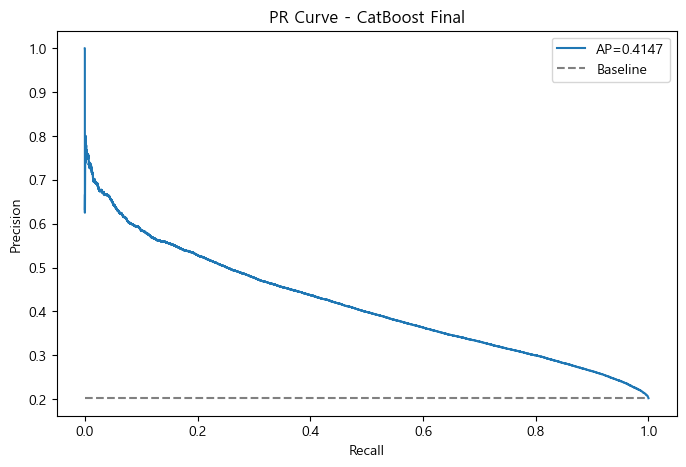

AUC: 0.7359
AP:  0.4147
              precision    recall  f1-score   support

       정상(0)       0.81      0.98      0.89    203905
       부도(1)       0.57      0.12      0.20     51655

    accuracy                           0.80    255560
   macro avg       0.69      0.55      0.54    255560
weighted avg       0.76      0.80      0.75    255560



In [ ]:
# 예측
y_pred = cat_final.predict(X_test)
proba  = cat_final.predict_proba(X_test)[:, 1]

# PR Curve
ap = average_precision_score(y_test, proba)
prec, rec, thresholds = precision_recall_curve(y_test, proba)

plt.figure(figsize=(8, 5))
plt.plot(rec, prec, label=f"AP={ap:.4f}")
plt.hlines(y_test.mean(), 0, 1, linestyles="--", color="gray", label="Baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - CatBoost Final")
plt.legend()
plt.show()

# 최종 지표
print(f"AUC: {roc_auc_score(y_test, proba):.4f}")
print(f"AP:  {ap:.4f}")
print(classification_report(y_test, y_pred, target_names=["정상(0)", "부도(1)"]))


# **AP(Average Precision) 해석:**

# Baseline(점선) = 부도 비율 = 0.2
# AP > 0.2 → 모델이 랜덤보다 나음
# AP → 1.0 에 가까울수록 우수

### 2단계 다시 AUC로 
- recall      0.12      0.20   

In [ ]:
param_grid_2 = {
    "depth": [3 ,4, 5, 6, 8, 10],
    "min_data_in_leaf": [1, 5, 10, 20]
}

gs_2_auc = GridSearchCV(
    CatBoostClassifier(
        iterations=497,
        learning_rate=0.1,
        l2_leaf_reg=1,         # 4단계 고정
        subsample=1.0,
        rsm=1.0, 
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0
    ),
    param_grid=param_grid_2,
    cv=5,
    scoring="roc_auc",         # AUC 기준
    n_jobs=-1
)

gs_2_auc.fit(X_sample, y_sample, cat_features=cat_cols)

best_depth = gs_2_auc.best_params_["depth"]
best_min_leaf = gs_2_auc.best_params_["min_data_in_leaf"]
print(f"Best depth: {best_depth}")
print(f"Best min_data_in_leaf: {best_min_leaf}")
print(f"Best AUC: {gs_2_auc.best_score_:.4f}")

# est depth: 6
# Best min_data_in_leaf: 1
# Best AUC: 0.9316

Best depth: 6
Best min_data_in_leaf: 1
Best AUC: 0.9316


In [ ]:
# 4단계 다시 :
# 샘플링 방법 개선 원본데이로 샘플링  
from catboost import CatBoostClassifier

X_sample = X_train.sample(frac=0.3, random_state=42)
y_sample = y_train[X_sample.index]

param_grid_4 = {
    "l2_leaf_reg": [1, 3, 5, 7, 10, 15, 20, 30],
}

gs_4 = GridSearchCV(
    CatBoostClassifier(
        iterations=497,
        learning_rate=0.1,
        depth=6,
        min_data_in_leaf=1,
        subsample=1.0,         # 3단계 고정
        rsm=1.0,               # 3단계 고정
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0
    ),
    param_grid=param_grid_4,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gs_4.fit(X_sample, y_sample, cat_features=cat_cols)


# 4단계 결과 출력
best_l2 = gs_4.best_params_["l2_leaf_reg"]
print(f"Best l2_leaf_reg: {best_l2}")
print(f"Best AUC: {gs_4.best_score_:.4f}")

# Best l2_leaf_reg: 10
# Best AUC: 0.7330

KeyError: 'min_data_in_leaf'

In [ ]:
# 5단계 Early Stopping (learning_rate 낮추고 iterations 늘리기)
# validation 분리 (X_train 기반)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_smote, y_smote, test_size=0.1, random_state=42
) # data 사이즈가 커서 0.1 로 충분 할 듯 

# 5단계 모델
cat_final = CatBoostClassifier(
    iterations=5000,           # lr 낮추므로 넉넉하게
    learning_rate=0.01,        # 0.1 → 0.01
    depth=6,
    min_data_in_leaf=1,
    subsample=1.0,
    rsm=1.0,
    l2_leaf_reg=10,            # 4단계 고정
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    cat_features=cat_cols
)

cat_final.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100
)


# bestTest = 0.9333196128
# bestIteration = 4999

# Best iteration: 4999

0:	test: 0.8235036	best: 0.8235036 (0)	total: 339ms	remaining: 28m 12s
100:	test: 0.9145777	best: 0.9145777 (100)	total: 30.2s	remaining: 24m 25s
200:	test: 0.9239258	best: 0.9239258 (200)	total: 1m 2s	remaining: 24m 46s
300:	test: 0.9261367	best: 0.9261367 (300)	total: 1m 33s	remaining: 24m 24s
400:	test: 0.9273183	best: 0.9273183 (400)	total: 2m 4s	remaining: 23m 51s
500:	test: 0.9281199	best: 0.9281199 (500)	total: 2m 38s	remaining: 23m 41s
600:	test: 0.9287855	best: 0.9287855 (600)	total: 3m 10s	remaining: 23m 16s
700:	test: 0.9292981	best: 0.9292981 (700)	total: 3m 40s	remaining: 22m 30s
800:	test: 0.9297290	best: 0.9297290 (800)	total: 4m 9s	remaining: 21m 46s
900:	test: 0.9300794	best: 0.9300794 (900)	total: 4m 38s	remaining: 21m 5s
1000:	test: 0.9303756	best: 0.9303756 (1000)	total: 5m 6s	remaining: 20m 25s
1100:	test: 0.9306198	best: 0.9306198 (1100)	total: 5m 36s	remaining: 19m 51s
1200:	test: 0.9308299	best: 0.9308299 (1200)	total: 6m 5s	remaining: 19m 16s
1300:	test: 0.9310

NameError: name 'roc_auc_score' is not defined

In [ ]:
print(f"Best iteration: {cat_final.best_iteration_}")

y_pred = cat_final.predict(X_test)
proba  = cat_final.predict_proba(X_test)[:, 1]
print(f"AUC: {roc_auc_score(y_test, proba):.4f}")
print(classification_report(y_test, y_pred, target_names=["정상(0)", "부도(1)"]))


Best iteration: 4999
AUC: 0.7361
              precision    recall  f1-score   support

       정상(0)       0.81      0.98      0.89    203905
       부도(1)       0.57      0.12      0.20     51655

    accuracy                           0.80    255560
   macro avg       0.69      0.55      0.54    255560
weighted avg       0.77      0.80      0.75    255560



### 최종모델

In [ ]:
# 최종 모델 학습
# cat_final.fit(X_smote) → 최종 학습

# 최종 학습 (best_iteration 반영 + X_smote 전체)
cat_final_full = CatBoostClassifier(
    iterations= 4999 ,  # 5단계 best iteration 고정
    learning_rate=0.01,
    depth=6,
    min_data_in_leaf=1, 
    subsample=1.0, 
    rsm=1.0,
    l2_leaf_reg=10, 
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    cat_features=cat_cols
)

cat_final_full.fit(X_smote, y_smote)  # 전체 데이터로 재학습



0:	total: 983ms	remaining: 1h 21m 50s
100:	total: 45.9s	remaining: 37m 8s
200:	total: 1m 9s	remaining: 27m 42s
300:	total: 1m 34s	remaining: 24m 29s
400:	total: 1m 59s	remaining: 22m 46s
500:	total: 2m 25s	remaining: 21m 48s
600:	total: 2m 53s	remaining: 21m 11s
700:	total: 3m 19s	remaining: 20m 25s
800:	total: 3m 44s	remaining: 19m 36s
900:	total: 4m 9s	remaining: 18m 53s
1000:	total: 4m 33s	remaining: 18m 12s
1100:	total: 4m 58s	remaining: 17m 36s
1200:	total: 5m 22s	remaining: 16m 58s
1300:	total: 5m 46s	remaining: 16m 24s
1400:	total: 6m 9s	remaining: 15m 50s
1500:	total: 6m 34s	remaining: 15m 18s
1600:	total: 6m 57s	remaining: 14m 46s
1700:	total: 7m 21s	remaining: 14m 15s
1800:	total: 7m 44s	remaining: 13m 45s
1900:	total: 8m 8s	remaining: 13m 15s
2000:	total: 8m 31s	remaining: 12m 46s
2100:	total: 8m 55s	remaining: 12m 18s
2200:	total: 9m 19s	remaining: 11m 51s
2300:	total: 9m 44s	remaining: 11m 24s
2400:	total: 10m 7s	remaining: 10m 57s
2500:	total: 10m 31s	remaining: 10m 30s
2

CatBoostClassifier(cat_features=['term', 'sub_grade', 'purpose', 'issue_year', 'emp_length', 'home_ownership', 'mths_since_last_major_derog_flag', 'mths_since_recent_inq_flag', 'issue_month', 'earliest_cr_line_year'], depth=4, eval_metric='AUC', iterations=4999, l2_leaf_reg=10, learning_rate=0.01, loss_function='Logloss', min_data_in_leaf=1, random_seed=42, rsm=1.0, subsample=1.0, verbose=100)

In [ ]:
#  저장 
cat_final_full.save_model("./model/cat_final.cbm")

In [46]:
#  로드
from catboost import CatBoostClassifier
cat_loaded = CatBoostClassifier()
cat_loaded.load_model("./model/cat_final.cbm")
cat_final_full = cat_loaded
# 최종 평가
y_pred = cat_final_full.predict(X_test)
proba  = cat_final_full.predict_proba(X_test)[:, 1]

In [47]:
# 과적합 여부 탐색 
# train F1 vs test F1 비교
y_train_pred = cat_final_full.predict(X_smote)
print("Train F1:", classification_report(y_smote, y_train_pred, target_names=["정상(0)", "부도(1)"]))
print("Test F1:", classification_report(y_test, y_pred, target_names=["정상(0)", "부도(1)"]))

# 과적합 발생 
# >> 깊이조정 

Train F1:               precision    recall  f1-score   support

       정상(0)       0.81      0.98      0.89    815621
       부도(1)       0.97      0.78      0.86    815621

    accuracy                           0.88   1631242
   macro avg       0.89      0.88      0.88   1631242
weighted avg       0.89      0.88      0.88   1631242

Test F1:               precision    recall  f1-score   support

       정상(0)       0.81      0.98      0.89    203905
       부도(1)       0.58      0.12      0.20     51655

    accuracy                           0.80    255560
   macro avg       0.70      0.55      0.54    255560
weighted avg       0.77      0.80      0.75    255560



[F1 최대] thr=0.20  P=0.330  R=0.706  F1=0.449
[Recall≥0.9] thr=0.10  P=0.251  F1=0.395


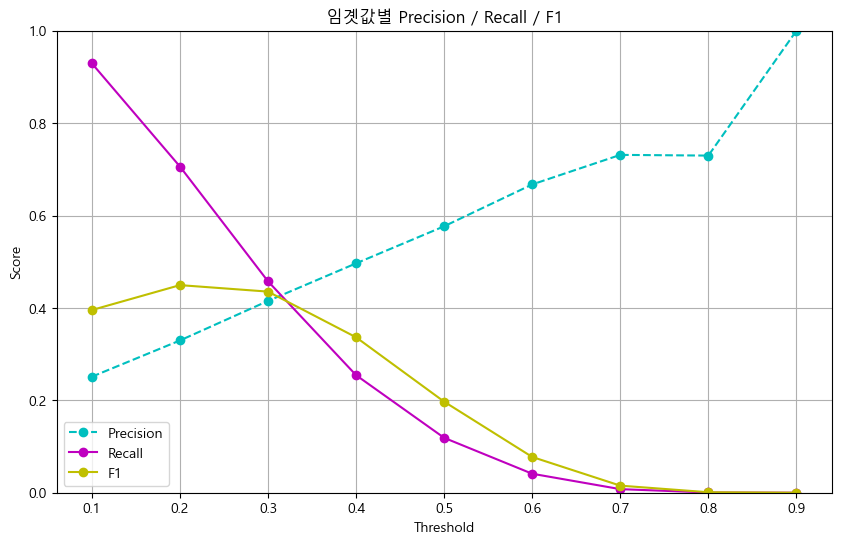

In [ ]:
# ============================================
# 임곗값별 Precision / Recall / F1 템플릿
# 어떤 모델이든 y_test와 y_proba만 있으면 바로 사용
# ============================================

# ── ① 여기만 바꾸면 됨 ──
y_test  
y_proba = proba  # 양성 확률

# ── ② 임곗값별 지표 계산 ──
thr_list = np.round(np.arange(0.1, 1.0, 0.1), 2)
rows = []
for thr in thr_list:
    y_hat = (y_proba >= thr).astype(int)
    rows.append([thr,
                 precision_score(y_test, y_hat, zero_division=0),
                 recall_score(y_test, y_hat, zero_division=0),
                 f1_score(y_test, y_hat, zero_division=0),
                 accuracy_score(y_test, y_hat)])

thr_df = pd.DataFrame(rows, columns=["threshold","precision","recall","f1","accuracy"])

# ── ③ F1 최대 / Recall 목표 자동 출력 ──
best = thr_df.iloc[thr_df["f1"].idxmax()]
print(f"[F1 최대] thr={best['threshold']:.2f}  P={best['precision']:.3f}  R={best['recall']:.3f}  F1={best['f1']:.3f}")

target_recall = 0.90   # ← 원하는 Recall 기준
cand = thr_df[thr_df["recall"] >= target_recall].sort_values("threshold", ascending=False)
print(f"[Recall≥{target_recall}]",
      "없음" if cand.empty else f"thr={cand.iloc[0]['threshold']:.2f}  P={cand.iloc[0]['precision']:.3f}  F1={cand.iloc[0]['f1']:.3f}")

# ── ④ 시각화 ──
plt.figure(figsize=(10, 6))
plt.plot(thr_df["threshold"], thr_df["precision"], "c--o", label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], "m-o", label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"], "y-o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("임곗값별 Precision / Recall / F1")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

In [50]:
# 임계값 0.2 4
# 임계값 0.2 적용
y_pred_02 = (proba >= 0.2).astype(int)

print(f"임계값: 0.2")
print(f"AUC: {roc_auc_score(y_test, proba):.4f}")
print(classification_report(y_test, y_pred_02, target_names=["정상(0)", "부도(1)"]))

# FN 원금 회수 불가 


임계값: 0.2
AUC: 0.7361
              precision    recall  f1-score   support

       정상(0)       0.90      0.64      0.74    203905
       부도(1)       0.33      0.71      0.45     51655

    accuracy                           0.65    255560
   macro avg       0.61      0.67      0.60    255560
weighted avg       0.78      0.65      0.68    255560



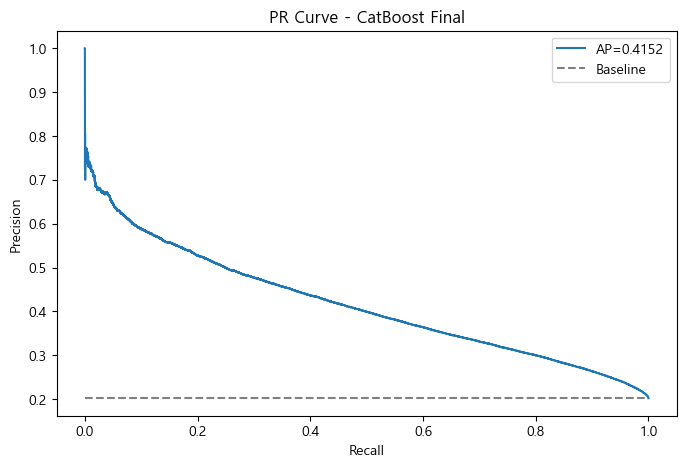

AUC: 0.7361
AP:  0.4152
              precision    recall  f1-score   support

       정상(0)       0.81      0.98      0.89    203905
       부도(1)       0.58      0.12      0.20     51655

    accuracy                           0.80    255560
   macro avg       0.70      0.55      0.54    255560
weighted avg       0.77      0.80      0.75    255560



In [ ]:
# 예측
y_pred = cat_final_full.predict(X_test)
proba  = cat_final_full.predict_proba(X_test)[:, 1]

# PR Curve
ap = average_precision_score(y_test, proba)
prec, rec, thresholds = precision_recall_curve(y_test, proba)

plt.figure(figsize=(8, 5))
plt.plot(rec, prec, label=f"AP={ap:.4f}")
plt.hlines(y_test.mean(), 0, 1, linestyles="--", color="gray", label="Baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - CatBoost Final")
plt.legend()
plt.show()

# 최종 지표
print(f"AUC: {roc_auc_score(y_test, proba):.4f}")
print(f"AP:  {ap:.4f}")
print(classification_report(y_test, y_pred, target_names=["정상(0)", "부도(1)"]))


[F1 최대] thr=0.20  P=0.330  R=0.706  F1=0.449
[Recall≥0.9] thr=0.10  P=0.251  F1=0.395


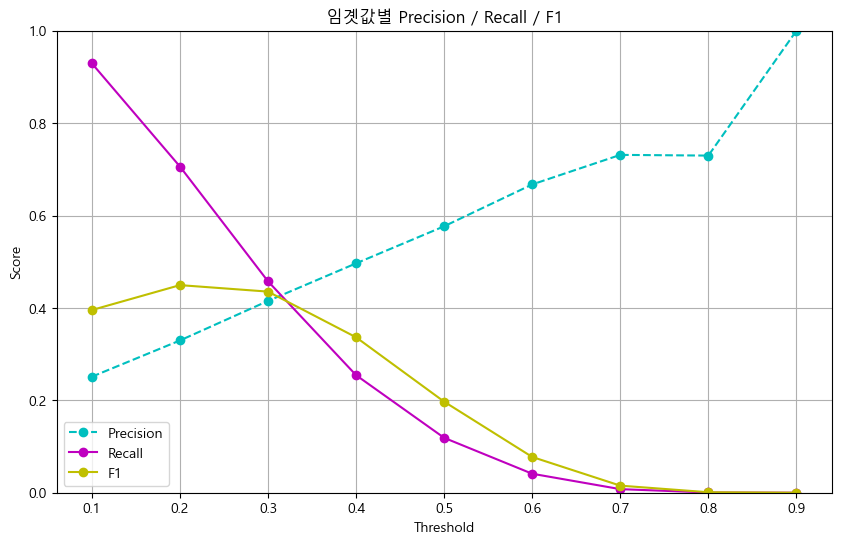

In [ ]:
# ============================================
# 임곗값별 Precision / Recall / F1 템플릿
# 어떤 모델이든 y_test와 y_proba만 있으면 바로 사용
# ============================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ── ① 여기만 바꾸면 됨 ──
y_test  
y_proba = proba  # 양성 확률

# ── ② 임곗값별 지표 계산 ──
thr_list = np.round(np.arange(0.1, 1.0, 0.1), 2)
rows = []
for thr in thr_list:
    y_hat = (y_proba >= thr).astype(int)
    rows.append([thr,
                 precision_score(y_test, y_hat, zero_division=0),
                 recall_score(y_test, y_hat, zero_division=0),
                 f1_score(y_test, y_hat, zero_division=0),
                 accuracy_score(y_test, y_hat)])

thr_df = pd.DataFrame(rows, columns=["threshold","precision","recall","f1","accuracy"])

# ── ③ F1 최대 / Recall 목표 자동 출력 ──
best = thr_df.iloc[thr_df["f1"].idxmax()]
print(f"[F1 최대] thr={best['threshold']:.2f}  P={best['precision']:.3f}  R={best['recall']:.3f}  F1={best['f1']:.3f}")

target_recall = 0.90   # ← 원하는 Recall 기준
cand = thr_df[thr_df["recall"] >= target_recall].sort_values("threshold", ascending=False)
print(f"[Recall≥{target_recall}]",
      "없음" if cand.empty else f"thr={cand.iloc[0]['threshold']:.2f}  P={cand.iloc[0]['precision']:.3f}  F1={cand.iloc[0]['f1']:.3f}")

# ── ④ 시각화 ──
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(thr_df["threshold"], thr_df["precision"], "c--o", label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], "m-o", label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"], "y-o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("임곗값별 Precision / Recall / F1")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

In [54]:
# 0.2 기준 결과 확인
y_pred_02 = (proba >= 0.2).astype(int)
print(classification_report(y_test, y_pred_02, target_names=["정상(0)", "부도(1)"]))

              precision    recall  f1-score   support

       정상(0)       0.90      0.64      0.74    203905
       부도(1)       0.33      0.71      0.45     51655

    accuracy                           0.65    255560
   macro avg       0.61      0.67      0.60    255560
weighted avg       0.78      0.65      0.68    255560



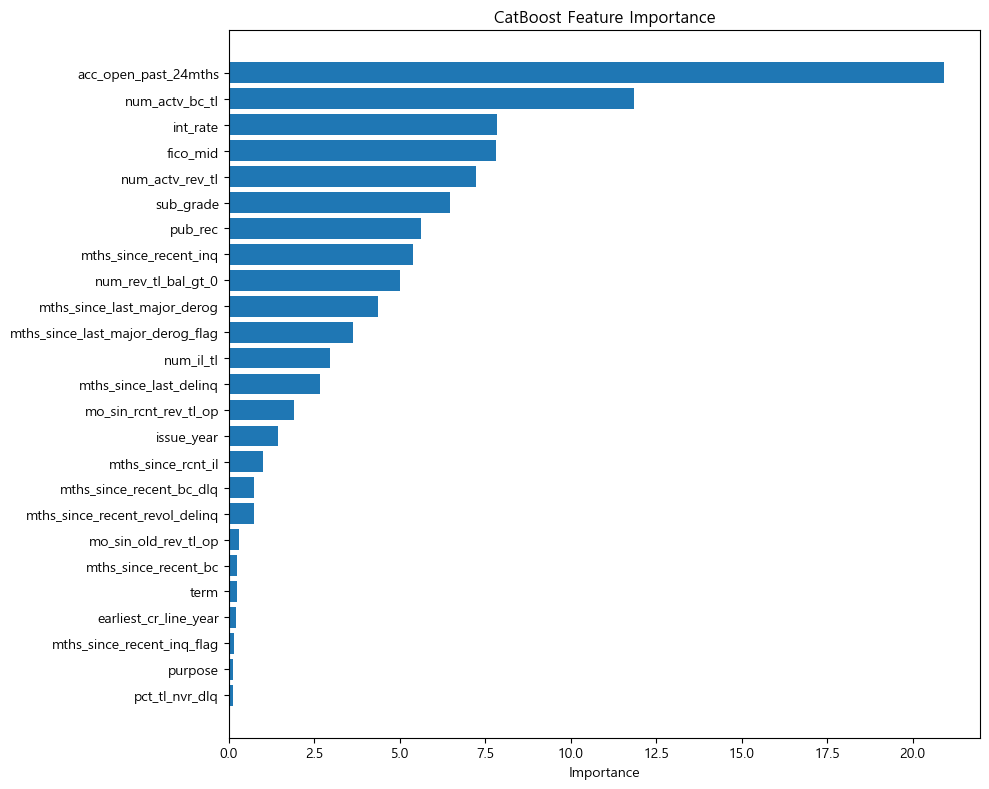

In [ ]:
# 1. 피처 중요도 추출
feature_importance = pd.DataFrame({
    "feature": X_tr.columns,
    "importance": cat_final_full.get_feature_importance()
}).sort_values("importance", ascending=False)

# 2. 상위 25개 시각화
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance["feature"][:25][::-1],
    feature_importance["importance"][:25][::-1]
)
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### SHAP 

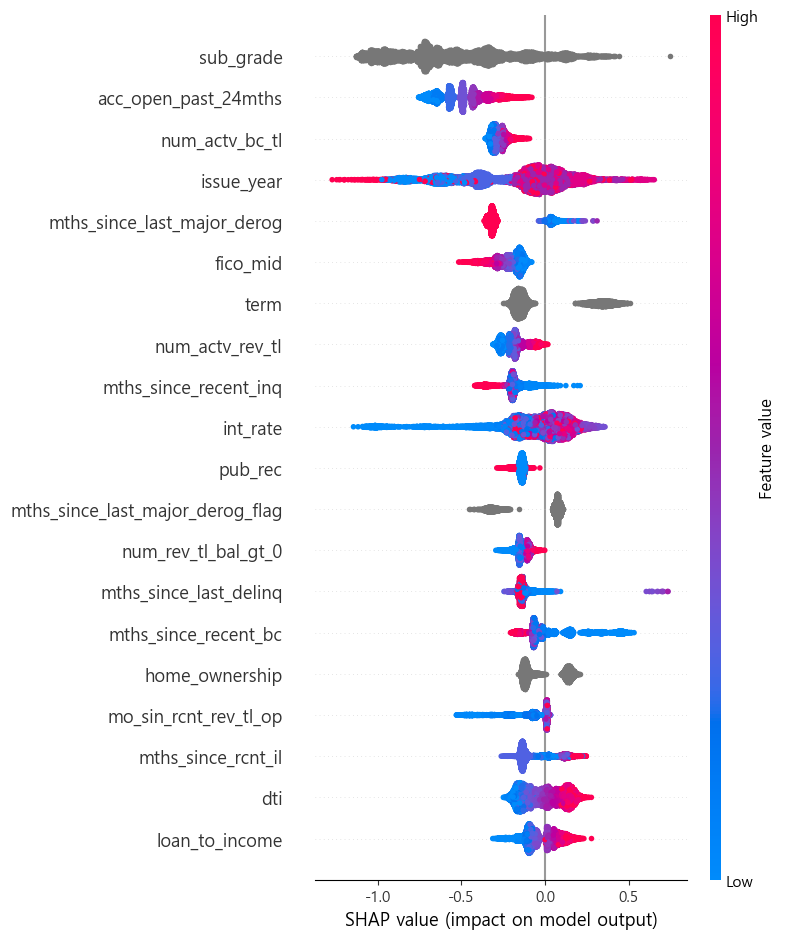

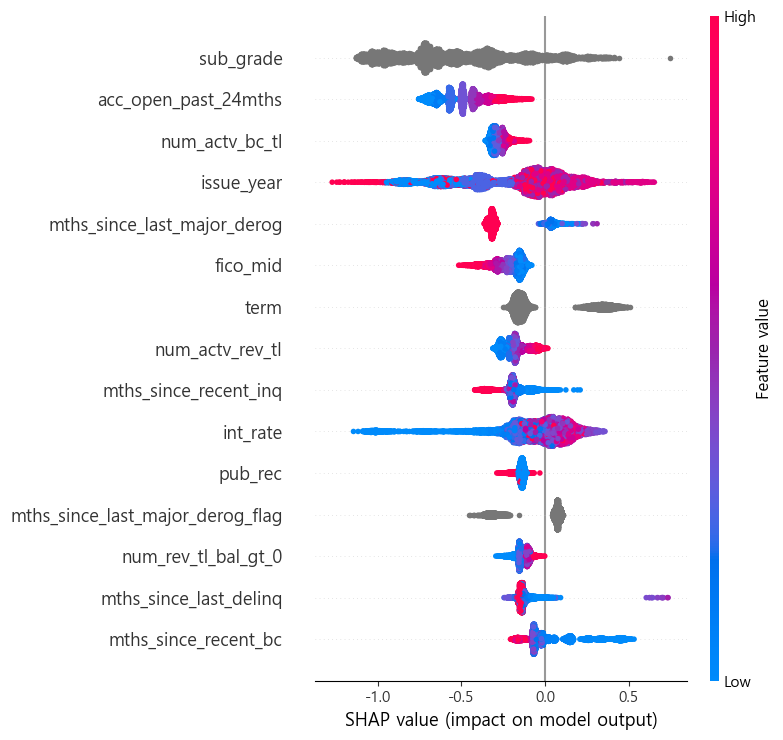

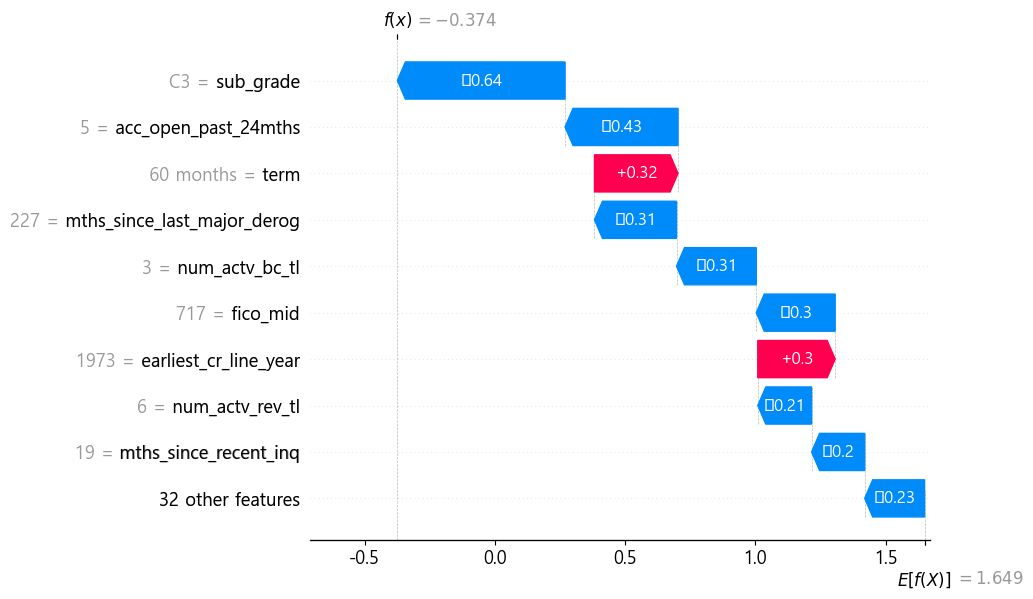

In [ ]:
# 1. explainer 생성
explainer = shap.TreeExplainer(cat_final_full)

# 2. 샘플링 (전체 X_test는 시간 오래 걸림)
X_shap = X_test.sample(10000, random_state=42)
shap_values = explainer.shap_values(X_shap)

# 3. 전체 피처 중요도
shap.summary_plot(shap_values, X_shap)

# 4. 상위 15개만
shap.summary_plot(shap_values, X_shap, max_display=15)

# 5. 개별 예측 설명 (첫 번째 샘플)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[1],
        base_values=explainer.expected_value,
        data=X_shap.iloc[1]
    )
)